# Supervised HMM + regime MVO

Strategy `regime_mvo`: forecast the dominant 60-day regime and train MVO on historical days with that label.

Synthetic-data improvements vs the earlier skip-only design:
1. Prefer **high-stress** synthetic series when augmenting.
2. Augment by **row-appending** observations (not expanding the asset dimension).
3. If the forecast regime has too few historical days, **fill with stress synthetic rows** when `n_synth>0` instead of skipping.
4. Report **paired crisis deltas** and win rates vs `n_synth=0`.

Plots are kept aligned with the core Data_5 comparisons (Sharpe/Calmar curves, shocks, multi-seed bands, Split-B wealth, correlations).

Open this notebook with working directory `evaluation/`.


## 1. Data loading and configuration

In [77]:
from __future__ import annotations

import importlib
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data_utils import load_real_data
from portfolio_core import TRADING_DAYS, pct_returns, sharpe_ratio, summarize_portfolio
from portfolio_eval_final import plot_metric_curve

EVAL_DIR = Path(".").resolve()
PROJECT_ROOT = EVAL_DIR.parent
if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))

import supervised_hmm
import regime_hmm_mvo as regime_mvo

supervised_hmm = importlib.reload(supervised_hmm)
regime_mvo = importlib.reload(regime_mvo)

delta_vs_no_synth = regime_mvo.delta_vs_no_synth
summarize_synth_deltas = regime_mvo.summarize_synth_deltas
market_regime_signal = regime_mvo.market_regime_signal
run_regime_mvo_experiment = regime_mvo.run_regime_mvo_experiment
run_regime_mvo_path = regime_mvo.run_regime_mvo_path
shock_test_regime_mvo = regime_mvo.shock_test_regime_mvo
standardize_history = regime_mvo.standardize_history
identify_regimes = supervised_hmm.identify_regimes
fit_supervised_hmm = supervised_hmm.fit_supervised_hmm
STRATEGY_NAME = regime_mvo.STRATEGY_NAME
SOFT_MIN_TRAIN = regime_mvo.SOFT_MIN_TRAIN


In [78]:
TEST_RUN_DIR = (PROJECT_ROOT / "results" / "450_discrete_DDPM_0.7473").resolve()
GENERATED_CSV = TEST_RUN_DIR / "generated_data.csv"
SYNTH_DIR = TEST_RUN_DIR / "notebook_data5"
BENCHMARK_CSV = EVAL_DIR / "data" / "benchmark" / "benchmark_data.csv"

ASSET_COLS = [
    "A001", "A004", "A006", "A008", "A009",
    "A011", "A012", "A013", "A014", "A015",
]

INVEST = 60
STEP = 60                  # non-overlapping test windows
N_REGIMES = 5
VOL_WINDOW = 20            # EWM volatility span
MIN_SEGMENT_LENGTH = 32
MIN_HISTORY = 1260         # approximately five years
MIN_REGIME_TRAIN = 80      # target train size; synth fills when history is thinner
SOFT_MIN_TRAIN = 30        # skip only below this many historical regime days
MAX_REGIME_TRAIN = 504
MAX_WEIGHT = 0.30
MEAN_SHRINK = 0.50
MIX_GRID = (0, 1, 2, 5, 10, 20)
SEEDS = [42, 43, 44, 45, 46]
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("Generated CSV exists:", GENERATED_CSV.exists())
print("Strategy:", STRATEGY_NAME)
print("Soft min / target train:", SOFT_MIN_TRAIN, MIN_REGIME_TRAIN)


Project root: /Users/mohanyang/Desktop/ruya/Synthetic-data-tests
Generated CSV exists: True
Strategy: regime_mvo
Soft min / target train: 30 80


In [79]:
def ensure_notebook_synth_data() -> None:
    marker = SYNTH_DIR / "metadata.json"
    if marker.exists():
        return
    if not GENERATED_CSV.exists():
        raise FileNotFoundError(f"Missing generated data: {GENERATED_CSV}")
    script = PROJECT_ROOT / "train" / "scripts" / "convert_diffusion_generated_to_data5.py"
    cmd = [
        sys.executable, str(script),
        "--generated-csv", str(GENERATED_CSV),
        "--benchmark-csv", str(BENCHMARK_CSV),
        "--output-dir", str(SYNTH_DIR),
    ]
    print("Converting generated_data.csv -> notebook_data5 ...")
    subprocess.run(cmd, check=True, cwd=str(PROJECT_ROOT / "train"))


def load_synth_pool_data5(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0).astype(float)
    df.index = pd.to_datetime(df.index)
    return np.expm1(df)


ensure_notebook_synth_data()

df_real = load_real_data(str(BENCHMARK_CSV), benchmark=True)
df_real = df_real[ASSET_COLS].loc["2013-01-01":"2022-08-31"]
real_rets = pct_returns(df_real)

synth_pools = {
    asset: load_synth_pool_data5(
        SYNTH_DIR / f"{asset}_synthetic_log_returns_2013_2022_20seq.csv"
    )
    for asset in ASSET_COLS
}

print("Real returns:", real_rets.shape, real_rets.index[0].date(), "->", real_rets.index[-1].date())
for asset, pool in synth_pools.items():
    print(f"{asset}: {pool.shape[0]} rows x {pool.shape[1]} series")

Real returns: (2521, 10) 2013-01-02 -> 2022-08-31
A001: 2521 rows x 20 series
A004: 2521 rows x 20 series
A006: 2521 rows x 20 series
A008: 2521 rows x 20 series
A009: 2521 rows x 20 series
A011: 2521 rows x 20 series
A012: 2521 rows x 20 series
A013: 2521 rows x 20 series
A014: 2521 rows x 20 series
A015: 2521 rows x 20 series


## 2. Market-level return signal

The original setup models one benchmark return series. Here, one equal-weight return across the ten portfolio assets provides the shared market signal. Individual assets do not receive separate regime labels.

In [80]:
market = market_regime_signal(real_rets, ASSET_COLS)
market.describe()

count    2521.000000
mean        0.000245
std         0.006009
min        -0.073064
25%        -0.002114
50%         0.000424
75%         0.002995
max         0.054222
Name: market_return, dtype: float64

## 3. Regime labels and supervised Gaussian HMM

The method first standardizes log returns, computes exponentially weighted moving volatility, detects volatility change points, and clusters contiguous segments into five regimes using spectral clustering. Regime IDs are ordered from lowest to highest volatility.

During HMM training, both the regime state and return emission are observed. The transition rows use a Dirichlet prior concentration `1 / N_REGIMES`; each state emits a Gaussian return. Forward-backward gives posterior state probabilities for observed data. Future occupancy is forecast causally from the final filtered state.

In [81]:
standardized_market, _, _ = standardize_history(market)
regime_labels, regime_diagnostics = identify_regimes(
    standardized_market.to_numpy(),
    n_regimes=N_REGIMES,
    volatility_window=VOL_WINDOW,
    min_segment_length=MIN_SEGMENT_LENGTH,
    random_state=RANDOM_STATE,
)
hmm_model = fit_supervised_hmm(
    standardized_market.to_numpy(),
    regime_labels,
    n_regimes=N_REGIMES,
)
_, forecast_occupancy, predicted_regime = hmm_model.forecast_occupancy(
    standardized_market.to_numpy(),
    horizon=INVEST,
)

print("Regime counts:", np.bincount(regime_labels, minlength=N_REGIMES))
print("Mean regime volatility:", np.round(regime_diagnostics["regime_mean_volatility"], 4))
print("Transition matrix:\n", np.round(hmm_model.transmat_, 3))
print("Emission means:", np.round(hmm_model.means_, 4))
print("Emission variances:", np.round(hmm_model.variances_, 4))
print("60-day occupancy:", np.round(forecast_occupancy, 3))
print("Dominant forecast regime:", predicted_regime)

Regime counts: [1990  389   46   44   52]
Mean regime volatility: [0.663  1.0978 1.1888 1.9033 3.7017]
Transition matrix:
 [[0.997 0.002 0.    0.    0.001]
 [0.006 0.99  0.003 0.001 0.001]
 [0.026 0.004 0.962 0.004 0.004]
 [0.027 0.004 0.004 0.96  0.004]
 [0.004 0.004 0.004 0.023 0.966]]
Emission means: [ 0.0248 -0.1353  0.238   0.2957 -0.316 ]
Emission variances: [ 0.45    1.411   1.275   2.7406 16.0565]
60-day occupancy: [0.214 0.674 0.075 0.021 0.016]
Dominant forecast regime: 1


## 4. Rolling regime MVO backtest

For every non-overlapping 60-day test window, the HMM is refit on history only and forecasts the dominant regime.

Training rules:
- Use recent historical days with that regime label (up to 504).
- If historical days `< SOFT_MIN_TRAIN` (30): skip.
- If historical days `< MIN_REGIME_TRAIN` (80) and `n_synth>0`: **row-append stress-ranked synthetic observations** to reach the target size (this is the scarce-regime fill).
- Additional synthetic rows scale with `n_synth` (`21` rows per series).
- Baseline `n_synth=0` uses the thin historical sample when it clears the soft minimum, so paired deltas stay defined.

Portfolio: Ledoit–Wolf covariance, 50% mean shrinkage, long-only, 30% asset cap.


In [82]:
seed_runs = []
for seed in SEEDS:
    print(f"Running seed {seed} ...")
    seed_runs.append(
        run_regime_mvo_experiment(
            real_rets=real_rets,
            synth_pools=synth_pools,
            asset_cols=ASSET_COLS,
            mix_grid=MIX_GRID,
            invest=INVEST,
            step=STEP,
            min_history=MIN_HISTORY,
            n_regimes=N_REGIMES,
            volatility_window=VOL_WINDOW,
            min_segment_length=MIN_SEGMENT_LENGTH,
            min_regime_train=MIN_REGIME_TRAIN,
            soft_min_train=SOFT_MIN_TRAIN,
            max_regime_train=MAX_REGIME_TRAIN,
            max_weight=MAX_WEIGHT,
            mean_shrink=MEAN_SHRINK,
            objectives=("mean_variance", "min_variance"),
            seed=seed,
            random_state=RANDOM_STATE,
        )
    )

results = pd.concat(seed_runs, ignore_index=True)
print(results.shape)
print(results.groupby(["strategy", "objective", "status"]).size())
results.head()


Running seed 42 ...


/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods

Running seed 43 ...


/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods

Running seed 44 ...


...

/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods

Running seed 46 ...


/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods

(735, 35)
strategy    objective      status       
regime_mvo  mean_variance  ok               605
                           ok_synth_fill     25
            min_variance   ok               105
dtype: int64


,seed,strategy,allow_short,test_start,test_end,predicted_regime,realized_dominant_regime,dominant_regime_accuracy,forecast_brier,forecast_occupancy,...,max_drawdown,VaR_5%,CVaR_5%,ann_mu,ann_sd,n_obs,status,max_weight_used,spy_sharpe,spy_calmar
0,42,regime_mvo,False,2017-11-01,2018-01-23,0,0,1.0,0.331098,"[0.48866755406146384, 0.07462515533257097, 0.0...",...,-0.014928,-0.005205,-0.005562,0.370611,0.064269,60,ok,0.3,6.988252,41.201085
1,42,regime_mvo,False,2017-11-01,2018-01-23,0,0,1.0,0.331098,"[0.48866755406146384, 0.07462515533257097, 0.0...",...,-0.014775,-0.005235,-0.006199,0.362686,0.066457,60,ok,0.3,6.988252,41.201085
2,42,regime_mvo,False,2017-11-01,2018-01-23,0,0,1.0,0.331098,"[0.48866755406146384, 0.07462515533257097, 0.0...",...,-0.017652,-0.005152,-0.005828,0.388310,0.065178,60,ok,0.3,6.988252,41.201085
3,42,regime_mvo,False,2017-11-01,2018-01-23,0,0,1.0,0.331098,"[0.48866755406146384, 0.07462515533257097, 0.0...",...,-0.013868,-0.005280,-0.006474,0.384181,0.070799,60,ok,0.3,6.988252,41.201085
4,42,regime_mvo,False,2017-11-01,2018-01-23,0,0,1.0,0.331098,"[0.48866755406146384, 0.07462515533257097, 0.0...",...,-0.019510,-0.006459,-0.007439,0.285655,0.070692,60,ok,0.3,6.988252,41.201085


## 5. Regime forecast diagnostics

The forecast is scored after each test window using dominant-regime accuracy and the squared error between forecast and realized regime occupancy.

In [83]:
forecast_diag = (
    results.loc[
        (results["n_synth_series"] == 0)
        & (results["objective"] == "mean_variance")
    ]
    .drop_duplicates(["seed", "test_start"])
)
print("Dominant-regime accuracy:", round(float(forecast_diag["dominant_regime_accuracy"].mean()), 4))
print("Mean occupancy Brier score:", round(float(forecast_diag["forecast_brier"].mean()), 4))
print("\nPredicted dominant regime counts:")
print(forecast_diag["predicted_regime"].value_counts().sort_index())
print("\nRealized dominant regime counts:")
print(forecast_diag["realized_dominant_regime"].value_counts().sort_index())
print("\nHistorical regime-train size by forecast regime:")
print(forecast_diag.groupby("predicted_regime")["n_hist_train"].describe()[["count", "mean", "min", "max"]])

window_matrices = (
    forecast_diag.sort_values("test_start")
    .drop_duplicates("test_start")
    ["transition_matrix"]
    .map(lambda matrix: np.asarray(matrix, dtype=float))
)
state_names = [f"Regime {state}" for state in range(N_REGIMES)]
latest_transition_matrix = window_matrices.iloc[-1]
mean_transition_matrix = np.mean(np.stack(window_matrices.to_list()), axis=0)

print("\nLatest estimated transition matrix:")
display(pd.DataFrame(latest_transition_matrix, index=state_names, columns=state_names).round(4))
print("Average estimated transition matrix across rebalance windows:")
display(pd.DataFrame(mean_transition_matrix, index=state_names, columns=state_names).round(4))


Dominant-regime accuracy: 0.2857
Mean occupancy Brier score: 0.6342

Predicted dominant regime counts:
predicted_regime
0    55
1    15
2    20
3    15
Name: count, dtype: int64

Realized dominant regime counts:
realized_dominant_regime
0    25
1    15
2    35
3    20
4    10
Name: count, dtype: int64

Historical regime-train size by forecast regime:
                  count        mean    min    max
predicted_regime                                 
0                  55.0  467.818182  106.0  504.0
1                  15.0  351.666667   47.0  504.0
2                  20.0  339.250000  243.0  504.0
3                  15.0  219.333333  189.0  249.0

Latest estimated transition matrix:


,Regime 0,Regime 1,Regime 2,Regime 3,Regime 4
Regime 0,0.9871,0.0009,0.0055,0.0009,0.0055
Regime 1,0.0007,0.9973,0.0018,0.0001,0.0001
Regime 2,0.0036,0.0036,0.9887,0.0036,0.0006
Regime 3,0.0022,0.0244,0.0022,0.9689,0.0022
Regime 4,0.0036,0.0036,0.0036,0.0214,0.9679


Average estimated transition matrix across rebalance windows:


,Regime 0,Regime 1,Regime 2,Regime 3,Regime 4
Regime 0,0.9936,0.0007,0.0019,0.0023,0.0015
Regime 1,0.0058,0.9807,0.0040,0.0071,0.0024
Regime 2,0.0420,0.0429,0.8333,0.0405,0.0414
Regime 3,0.0413,0.0477,0.0403,0.8272,0.0436
Regime 4,0.0420,0.0444,0.0457,0.0474,0.8205


## 6. Portfolio results and crisis-focused synthetic deltas

Primary claim check: does `n_synth>0` improve crisis windows relative to `n_synth=0` on the same dates?


In [84]:
valid_results = results.loc[results["status"].astype(str).str.startswith("ok")].copy()
print(results.groupby(["objective", "status"]).size())
print("\nSynth-fill rate (mean_variance):",
      float(valid_results.loc[valid_results["objective"].eq("mean_variance"), "used_synth_fill"].mean()))

mv = valid_results.loc[valid_results["objective"] == "mean_variance"].copy()
mv["regime"] = mv["bucket"]
display(mv.groupby(["regime", "n_synth_series"])[["sharpe", "calmar", "max_drawdown", "max_weight_used"]].mean().round(4))

delta = delta_vs_no_synth(results.loc[results["objective"] == "mean_variance"])
delta_summary = summarize_synth_deltas(delta, by=("bucket", "n_synth_series"))
print("\nPaired deltas vs n_synth=0 (positive delta_sharpe / delta_calmar = augmentation helped)")
display(delta_summary.round(4))


objective      status       
mean_variance  ok               605
               ok_synth_fill     25
min_variance   ok               105
dtype: int64

Synth-fill rate (mean_variance): 0.03968253968253968


sharpe  calmar  max_drawdown  max_weight_used
regime n_synth_series                                               
calm   0               1.4772  8.6129       -0.0479              0.3
       1               1.5428  8.5494       -0.0484              0.3
       2               1.5826  8.4219       -0.0483              0.3
       5               1.6872  9.7556       -0.0494              0.3
       10              1.5915  8.1859       -0.0515              0.3
       20              1.7138  9.3438       -0.0526              0.3
crisis 0               0.3733  7.4906       -0.0973              0.3
       1               0.3765  6.4259       -0.1037              0.3
       2               0.4262  6.4429       -0.1109              0.3
       5               0.5674  5.5731       -0.1228              0.3
       10              0.4471  4.2943       -0.1252              0.3
       20              0.3594  3.9730       -0.1286              0.3


Paired deltas vs n_synth=0 (positive delta_sharpe / delta_calmar = augmentation helped)


,bucket,n_synth_series,n_windows,delta_sharpe_mean,delta_sharpe_winrate,delta_calmar_mean,delta_calmar_winrate,delta_max_drawdown_mean,delta_max_drawdown_winrate,delta_CVaR_5%_mean,delta_CVaR_5%_winrate
0,calm,1,60,0.0656,0.5500,-0.0635,0.5333,-0.0005,0.5000,-0.0001,0.6167
1,calm,2,60,0.1055,0.5500,-0.1910,0.5167,-0.0004,0.5333,-0.0002,0.4833
2,calm,5,60,0.2101,0.5167,1.1427,0.5667,-0.0015,0.3833,-0.0006,0.4333
3,calm,10,60,0.1143,0.4167,-0.4271,0.4333,-0.0036,0.3167,-0.0010,0.4333
4,calm,20,60,0.2366,0.4833,0.7309,0.5167,-0.0047,0.3000,-0.0015,0.3667
5,crisis,1,45,0.0032,0.7111,-1.0647,0.7333,-0.0064,0.4889,-0.0026,0.4444
6,crisis,2,45,0.0529,0.6444,-1.0477,0.6222,-0.0136,0.3333,-0.0045,0.4222
7,crisis,5,45,0.1941,0.6667,-1.9175,0.6444,-0.0256,0.2667,-0.0076,0.3333
8,crisis,10,45,0.0739,0.5778,-3.1963,0.5556,-0.0279,0.2444,-0.0084,0.2222
9,crisis,20,45,-0.0139,0.6222,-3.5176,0.5778,-0.0314,0.2667,-0.0098,0.2000


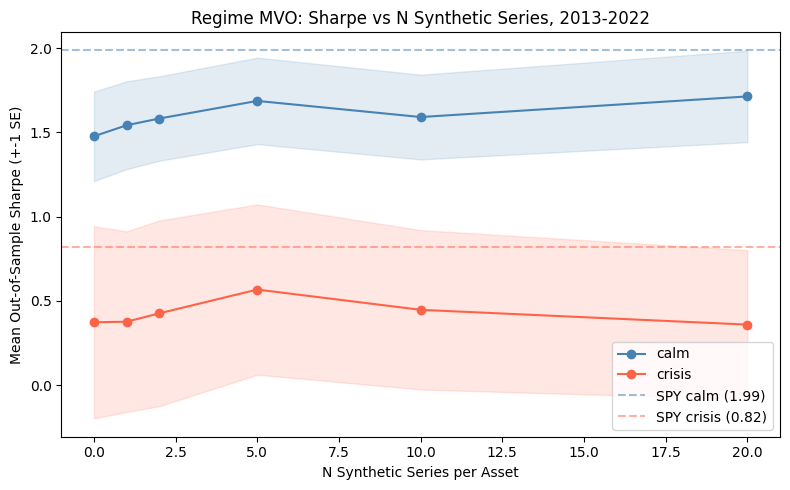

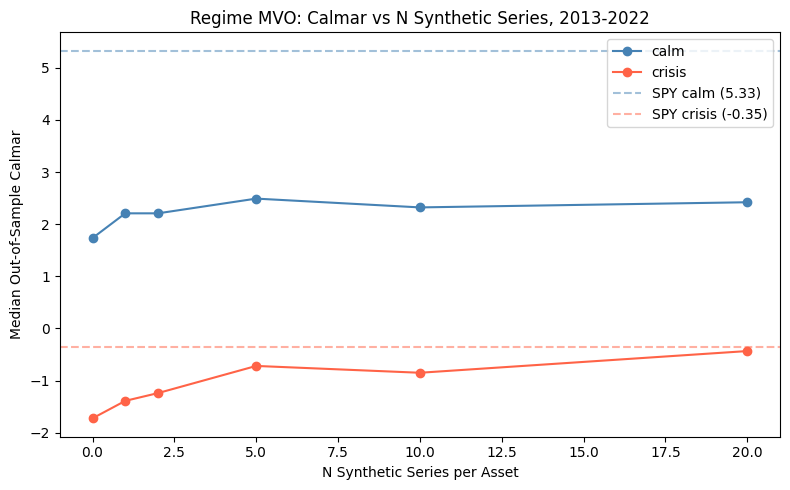

In [85]:
plot_metric_curve(
    mv, metric="sharpe", estimator="mean", spy_col="spy_sharpe",
    title="Regime MVO: Sharpe vs N Synthetic Series, 2013-2022",
)
plt.tight_layout(); plt.show()

plot_metric_curve(
    mv, metric="calmar", estimator="median", spy_col="spy_calmar",
    title="Regime MVO: Calmar vs N Synthetic Series, 2013-2022",
)
plt.tight_layout(); plt.show()


## 7. HMM-aligned shock testing

The Data_5 shock test trains on the last 252 mixed days, then applies shocks to the next 300 days. The old regime version used the HMM only to pick a training sample, then still shocked a 300-day window the 60-day forecast never prepared for.

This version uses the HMM for the test itself:

1. Forecast the dominant regime over the next 60 days.
2. Train **regime MVO** on historical days with that label.
3. Train **mixed MVO** on the last 252 days (same optimizer, same date).
4. Hold both portfolios for those same 60 days after applying the shock.

`REGIME_VOL` rescales the test window to the forecasted regime's historical volatility. Crisis shocks are still applied to every window. The plot below is high-vol forecasts only: regime MVO minus mixed MVO, repeated for each `n_synth`. Both methods get the same number of synthetic series.


/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/envs/diff/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods

method  vol_bucket  n_synth_series
mixed   high        0                  96
                    1                  96
                    2                  96
                    5                  96
                    10                 96
                    20                 96
        low         0                 288
                    1                 288
                    2                 288
                    5                 288
                    10                288
                    20                288
        mid         0                  80
                    1                  80
                    2                  80
                    5                  80
                    10                 80
                    20                 80
regime  high        0                  96
                    1                  96
                    2                  96
                    5                  96
                    10                 96

,bucket,sharpe_regime,calmar_regime,max_drawdown_regime,sharpe_mixed,calmar_mixed,max_drawdown_mixed
0,BASE,2.6310,7.8134,-0.0283,1.5694,5.5530,-0.0429
1,CORR_INFLATE_1.3,2.7216,7.9342,-0.0302,1.6433,5.7918,-0.0409
2,CRASH_2008,-1.4827,-5.4456,-0.9783,-1.4752,-5.4315,-0.9783
3,NEG_SHOCK_-10%,-1.3703,-2.2316,-0.1171,-1.1661,-1.6099,-0.1233
4,REGIME_VOL,2.6310,7.8542,-0.0511,1.5694,5.5693,-0.0628
5,SLOW_BLEED,-0.4791,-0.5960,-0.0377,-0.2826,-0.5568,-0.0505
6,VOL_SCALE_1.8x,2.6310,7.8567,-0.0507,1.5694,5.6166,-0.0763
7,WHIPSAW,-0.7703,-0.7748,-0.0973,-0.5063,-0.5687,-0.1047


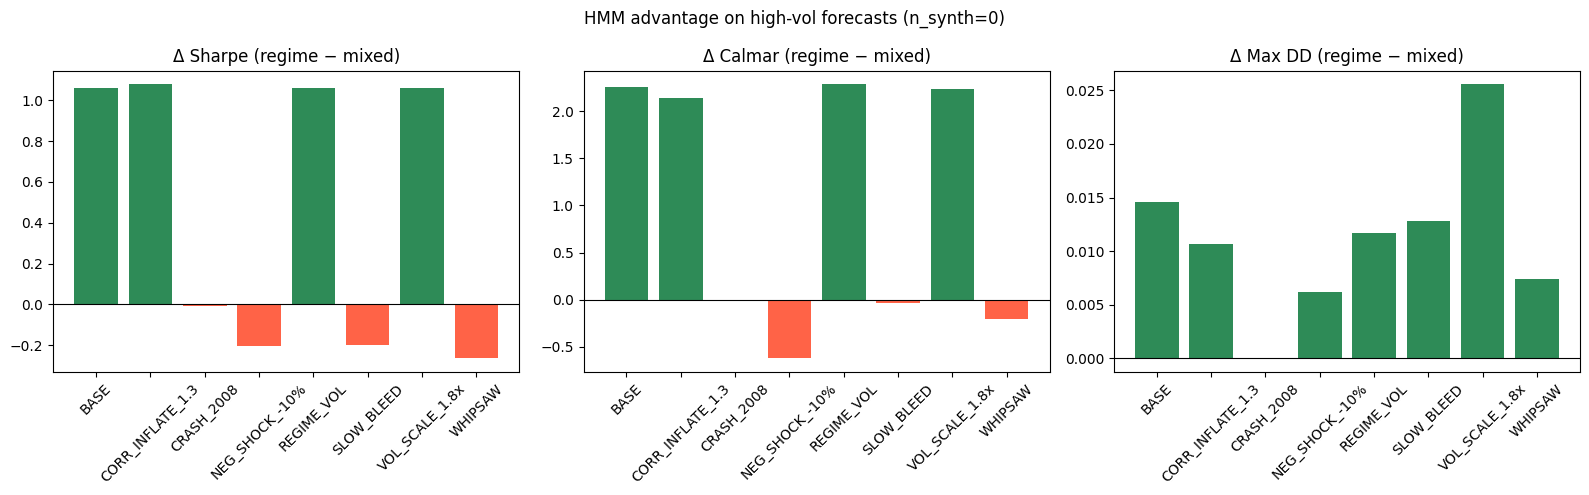

High-vol forecasts, n_synth=1


,bucket,sharpe_regime,calmar_regime,max_drawdown_regime,sharpe_mixed,calmar_mixed,max_drawdown_mixed
0,BASE,2.6450,7.2332,-0.0453,1.2312,4.2512,-0.0387
1,CORR_INFLATE_1.3,2.7834,8.3151,-0.0422,1.3530,4.6126,-0.0372
2,CRASH_2008,-1.4757,-5.4219,-0.9783,-1.4878,-5.4683,-0.9785
3,NEG_SHOCK_-10%,-1.1472,-2.2256,-0.1284,-1.3079,-2.1806,-0.1161
4,REGIME_VOL,2.6450,7.2418,-0.0494,1.2312,4.2719,-0.0666
5,SLOW_BLEED,0.2984,0.6222,-0.0501,-0.6028,-0.9558,-0.0497
6,VOL_SCALE_1.8x,2.6450,7.2823,-0.0808,1.2312,4.2806,-0.0692
7,WHIPSAW,-0.2562,-0.3808,-0.1005,-0.7418,-0.7687,-0.1047


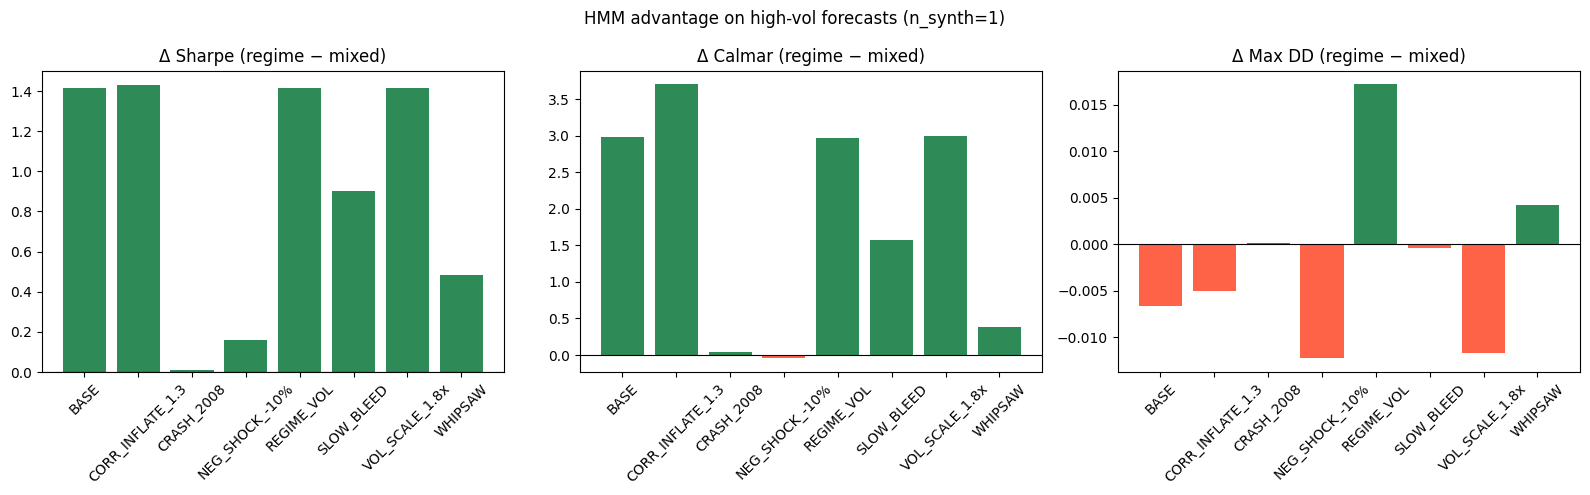

High-vol forecasts, n_synth=2


,bucket,sharpe_regime,calmar_regime,max_drawdown_regime,sharpe_mixed,calmar_mixed,max_drawdown_mixed
0,BASE,1.7288,4.6594,-0.0517,1.1167,2.9596,-0.0523
1,CORR_INFLATE_1.3,1.8135,5.0331,-0.0471,1.2754,3.3625,-0.0487
2,CRASH_2008,-1.4562,-5.3670,-0.9782,-1.4967,-5.4981,-0.9785
3,NEG_SHOCK_-10%,-1.0123,-1.5231,-0.1290,-1.3174,-1.9902,-0.1266
4,REGIME_VOL,1.7288,4.6689,-0.0614,1.1167,2.9819,-0.0830
5,SLOW_BLEED,0.4214,1.0563,-0.0627,-0.5579,-0.8598,-0.0633
6,VOL_SCALE_1.8x,1.7288,4.7192,-0.0919,1.1167,2.9871,-0.0932
7,WHIPSAW,-0.0669,-0.0307,-0.1010,-0.6386,-0.9091,-0.1132


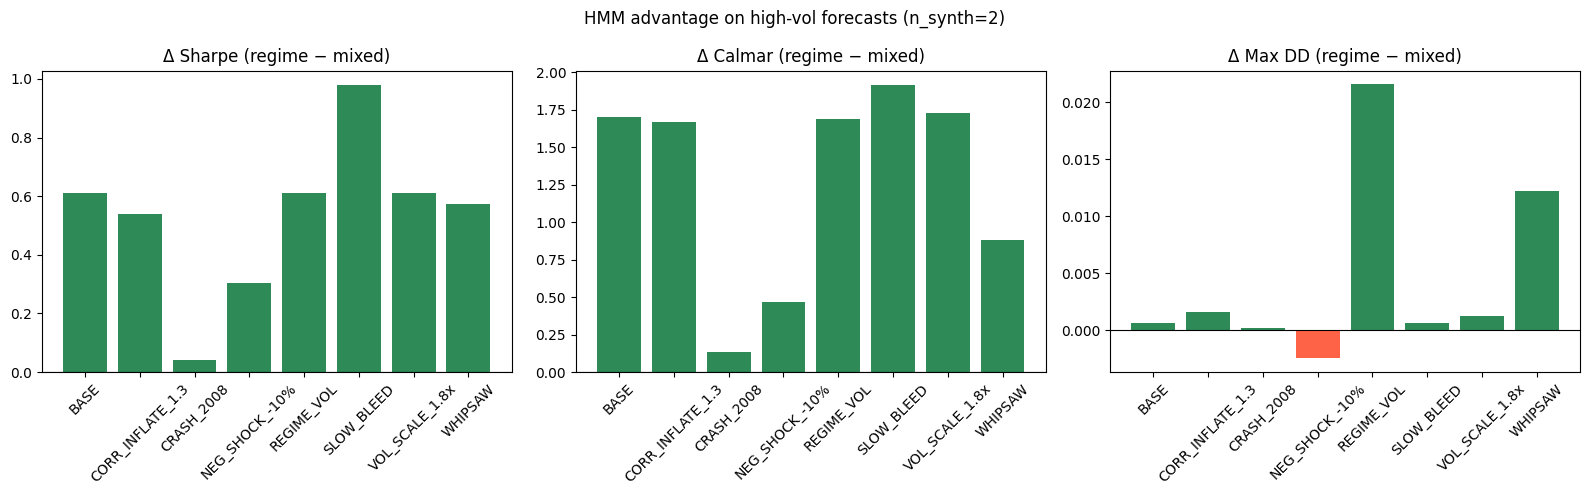

High-vol forecasts, n_synth=5


,bucket,sharpe_regime,calmar_regime,max_drawdown_regime,sharpe_mixed,calmar_mixed,max_drawdown_mixed
0,BASE,1.2882,3.6176,-0.0587,1.6368,5.1894,-0.0683
1,CORR_INFLATE_1.3,1.4202,4.0049,-0.0536,1.7456,5.3926,-0.0623
2,CRASH_2008,-1.4874,-5.4754,-0.9783,-1.4634,-5.3875,-0.9783
3,NEG_SHOCK_-10%,-1.2561,-1.8994,-0.1275,-0.9739,-1.7684,-0.1349
4,REGIME_VOL,1.2882,3.6318,-0.0859,1.6368,5.2240,-0.0983
5,SLOW_BLEED,-0.2962,-0.5159,-0.0635,0.1715,0.2664,-0.0752
6,VOL_SCALE_1.8x,1.2882,3.6389,-0.1047,1.6368,5.2342,-0.1208
7,WHIPSAW,-0.5193,-0.6861,-0.0958,-0.2338,-0.3396,-0.1070


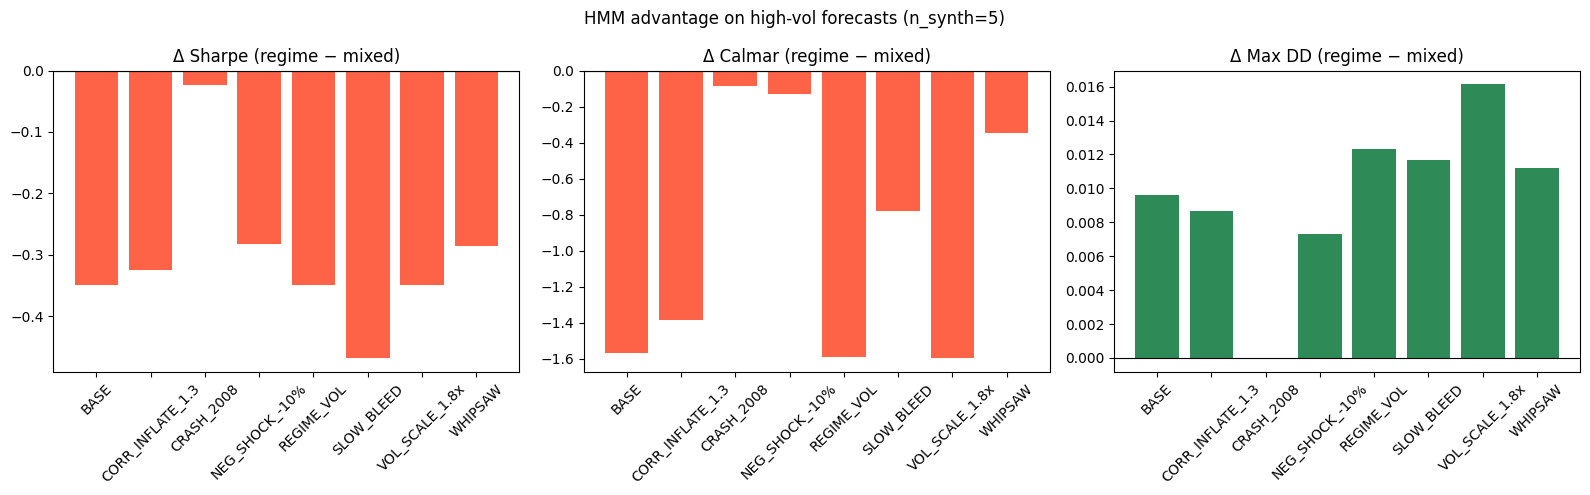

High-vol forecasts, n_synth=10


,bucket,sharpe_regime,calmar_regime,max_drawdown_regime,sharpe_mixed,calmar_mixed,max_drawdown_mixed
0,BASE,1.6689,4.6825,-0.0715,0.7918,2.1817,-0.0652
1,CORR_INFLATE_1.3,1.7612,5.0076,-0.0647,0.8218,2.3120,-0.0575
2,CRASH_2008,-1.4545,-5.3616,-0.9782,-1.4956,-5.5074,-0.9786
3,NEG_SHOCK_-10%,-0.8537,-1.3940,-0.1318,-1.2271,-2.0169,-0.1330
4,REGIME_VOL,1.6689,4.6954,-0.1004,0.7918,2.1962,-0.0963
5,SLOW_BLEED,0.4530,1.0761,-0.0736,-0.3571,-0.6185,-0.0671
6,VOL_SCALE_1.8x,1.6689,4.7673,-0.1265,0.7918,2.2044,-0.1155
7,WHIPSAW,0.0360,0.0868,-0.1035,-0.5495,-0.7718,-0.1098


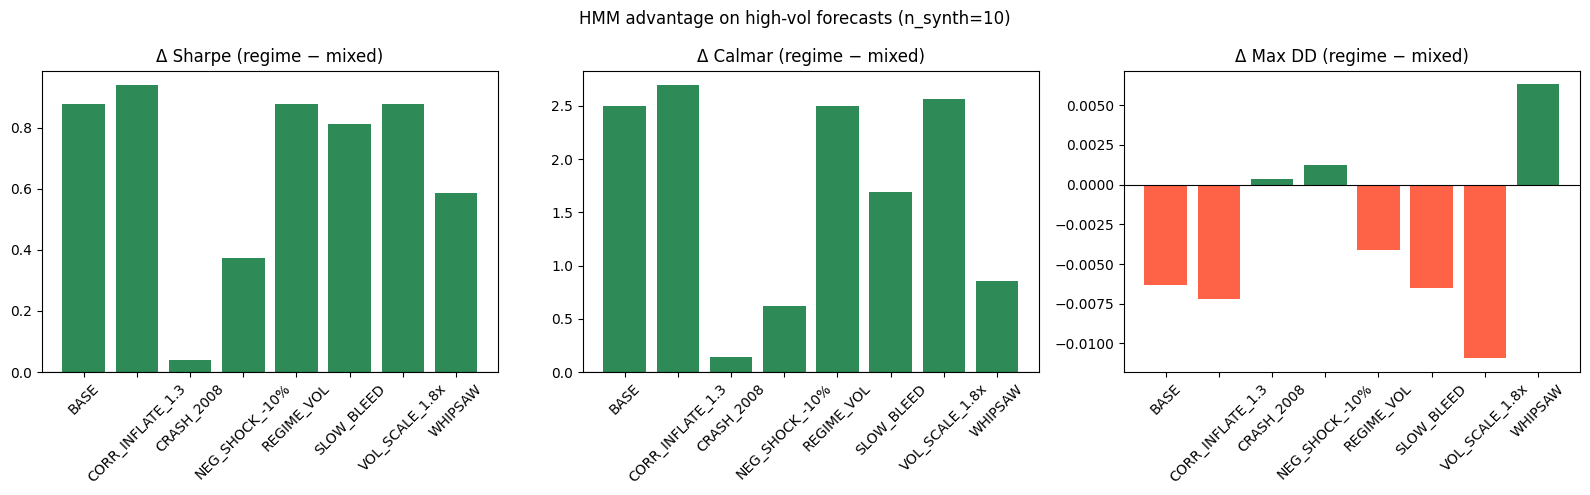

High-vol forecasts, n_synth=20


,bucket,sharpe_regime,calmar_regime,max_drawdown_regime,sharpe_mixed,calmar_mixed,max_drawdown_mixed
0,BASE,2.0332,5.5391,-0.0764,1.1119,3.2352,-0.0883
1,CORR_INFLATE_1.3,2.0892,5.7886,-0.0685,1.2690,3.6312,-0.0777
2,CRASH_2008,-1.4399,-5.3092,-0.9780,-1.4745,-5.4281,-0.9782
3,NEG_SHOCK_-10%,-0.7455,-1.2921,-0.1312,-1.1069,-1.7131,-0.1459
4,REGIME_VOL,2.0332,5.5593,-0.0948,1.1119,3.2637,-0.0915
5,SLOW_BLEED,0.8217,2.0993,-0.0793,-0.1863,-0.3788,-0.0904
6,VOL_SCALE_1.8x,2.0332,5.6401,-0.1349,1.1119,3.2723,-0.1553
7,WHIPSAW,0.3239,0.4407,-0.1082,-0.5137,-0.6698,-0.1188


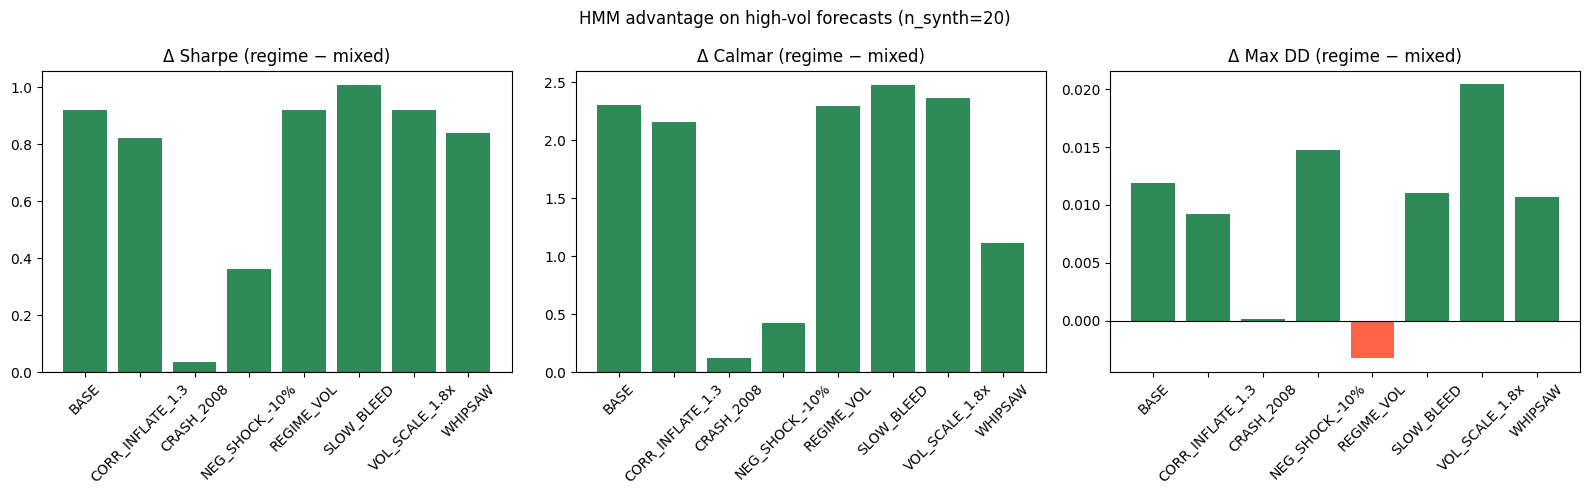

In [86]:
SHOCK_INVEST, SHOCK_STEP = INVEST, 21
CUSTOM_SCENARIOS = [
    ("BASE", {"shock_type": "VOL_SCALE", "vol_scale": 1.0}),
    ("REGIME_VOL", {"shock_type": "REGIME_VOL"}),
    ("VOL_SCALE_1.8x", {"shock_type": "VOL_SCALE", "vol_scale": 1.8}),
    ("NEG_SHOCK_-10%", {"shock_type": "NEG_RETURN_SHOCK", "shock_size": 0.10}),
    ("CORR_INFLATE_1.3", {"shock_type": "CORR_INFLATE", "corr_inflate": 1.3}),
    ("WHIPSAW", {"shock_type": "WHIPSAW"}),
    ("SLOW_BLEED", {"shock_type": "SLOW_BLEED"}),
    ("CRASH_2008", {"shock_type": "crash_2008"}),
]
SHOCK_NS = [0, 1, 2, 5, 10, 20]
metrics = ["sharpe", "calmar", "max_drawdown"]

shock_df = pd.concat(
    [
        shock_test_regime_mvo(
            real_rets=real_rets, synth_pools=synth_pools, asset_cols=ASSET_COLS,
            n_synth_series=int(n), investment_window=SHOCK_INVEST, window_step=SHOCK_STEP,
            min_history=MIN_HISTORY, invest_forecast=INVEST, n_regimes=N_REGIMES,
            volatility_window=VOL_WINDOW, min_segment_length=MIN_SEGMENT_LENGTH,
            min_regime_train=MIN_REGIME_TRAIN, soft_min_train=SOFT_MIN_TRAIN,
            max_regime_train=MAX_REGIME_TRAIN, max_weight=MAX_WEIGHT, mean_shrink=MEAN_SHRINK,
            seed=RANDOM_STATE, random_state=RANDOM_STATE, scenarios=CUSTOM_SCENARIOS,
        )
        for n in SHOCK_NS
    ],
    ignore_index=True,
)
print(shock_df.groupby(["method", "vol_bucket", "n_synth_series"]).size())

def _median_table(df):
    return df.groupby("bucket")[metrics].median().reset_index()

high = shock_df.loc[shock_df["vol_bucket"].eq("high")]
if high.empty:
    print("No high-vol forecast windows in this sample.")
else:
    for n in SHOCK_NS:
        sub = high.loc[high["n_synth_series"].eq(n)]
        reg = _median_table(sub.loc[sub["method"].eq("regime")]).rename(
            columns={m: f"{m}_regime" for m in metrics}
        )
        mix = _median_table(sub.loc[sub["method"].eq("mixed")]).rename(
            columns={m: f"{m}_mixed" for m in metrics}
        )
        vs = reg.merge(mix, on="bucket")
        print(f"High-vol forecasts, n_synth={n}")
        display(vs.round(4))
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, metric, ylabel in zip(axes, metrics, ["Δ Sharpe", "Δ Calmar", "Δ Max DD"]):
            delta = vs[f"{metric}_regime"] - vs[f"{metric}_mixed"]
            ax.bar(vs["bucket"], delta, color=["seagreen" if v >= 0 else "tomato" for v in delta])
            ax.axhline(0, color="black", lw=0.8)
            ax.set_title(f"{ylabel} (regime − mixed)")
            ax.tick_params(axis="x", rotation=45)
        plt.suptitle(f"HMM advantage on high-vol forecasts (n_synth={n})")
        plt.tight_layout()
        plt.show()


## 8. Multi-seed uncertainty (calm vs crisis)


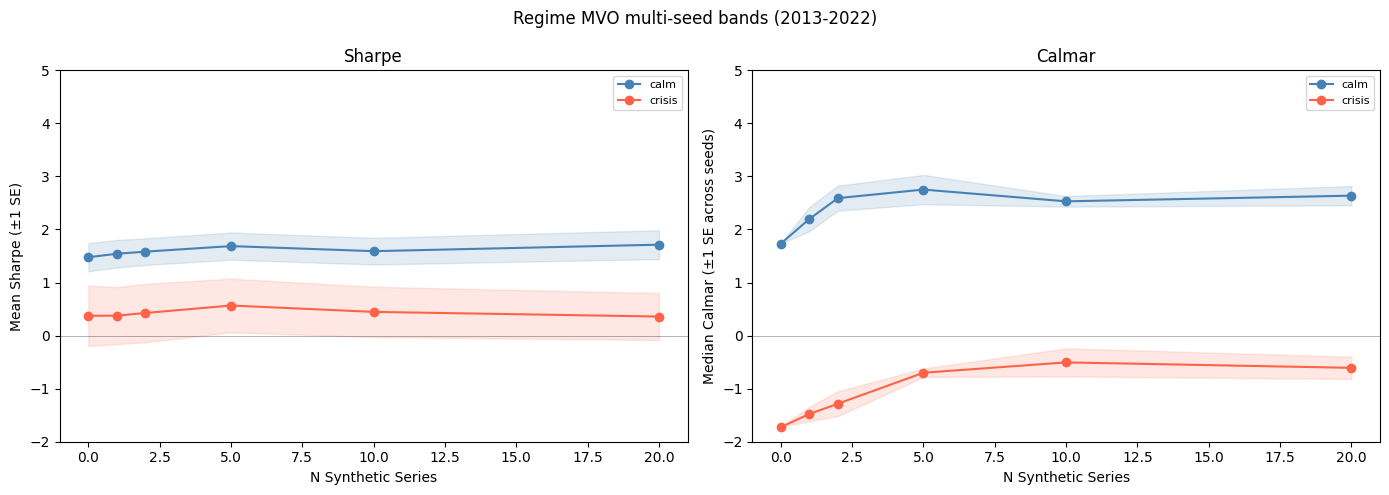

In [87]:
colors = {"calm": "steelblue", "crisis": "tomato"}
BAND_YLIM = (-2.0, 5.0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metric, est, ylabel in [
    (axes[0], "sharpe", "mean", "Mean Sharpe (±1 SE)"),
    (axes[1], "calmar", "median", "Median Calmar (±1 SE across seeds)"),
]:
    if metric == "sharpe":
        agg = mv.groupby(["regime", "n_synth_series"])[metric].agg(["mean", "sem"]).reset_index()
        y, e = "mean", "sem"
    else:
        per = mv.groupby(["seed", "regime", "n_synth_series"])[metric].median().reset_index()
        agg = per.groupby(["regime", "n_synth_series"])[metric].agg(["mean", "std", "count"]).reset_index()
        agg["sem"] = agg["std"] / np.sqrt(agg["count"])
        y, e = "mean", "sem"
    for regime, grp in agg.groupby("regime"):
        grp = grp.sort_values("n_synth_series")
        c = colors[regime]
        ax.plot(grp["n_synth_series"], grp[y], marker="o", color=c, label=regime)
        ax.fill_between(grp["n_synth_series"], grp[y]-grp[e], grp[y]+grp[e], alpha=0.15, color=c)
    ax.axhline(0, color="black", lw=0.6, alpha=0.35)
    ax.set_ylim(*BAND_YLIM)
    ax.set_xlabel("N Synthetic Series")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
axes[1].tick_params(labelleft=True)
axes[0].set_title("Sharpe")
axes[1].set_title("Calmar")
plt.suptitle("Regime MVO multi-seed bands (2013-2022)")
plt.tight_layout(); plt.show()


## Notes

- Implemented: stress-ranked synthetic selection, row-append augmentation, scarce-regime synth fill, crisis paired deltas / win rates, concentration via `max_weight_used`.
- Shock tests now use the HMM forecast horizon (60 days), a mixed-lookback baseline on the same dates, and `REGIME_VOL` (test vol scaled to the forecasted regime).
- Stress synthetic fill in shocks is used only when the forecast is high-vol.
- Skipped on purpose: occupancy-weighted training, forcing Data_5 `STEP` to 60, full covariance-blend rewrite of Data_5 column-stacking.
- `status`: `ok`, `ok_synth_fill`, or `skipped_insufficient_regime_sample`.
